In [47]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt

# How do customer experiences connect to broader business outcomes?

## Basic Exploration

### Customer Support Tickets

In [48]:
customer_support_tickets = pd.read_csv(
    "/home/rushik-sriramoju/AtlassianDatathon/customer_support_tickets.csv"
)

customer_support_tickets.head()
print(customer_support_tickets.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Status', 'Resolution',
       'Ticket Priority', 'Ticket Channel', 'First Response Time',
       'Time to Resolution', 'Customer Satisfaction Rating'],
      dtype='str')


In [49]:
customer_support_tickets["Ticket Subject"]

0                    Product setup
1                      Integration
2                  Network problem
3                   Account access
4                        Data loss
                   ...            
8464          Installation support
8465                Refund request
8466                Account access
8467                 Payment issue
8468    Device compatibility issue
Name: Ticket Subject, Length: 8469, dtype: str

In [50]:
customer_support_tickets["Customer Satisfaction Rating"].max()

np.float64(5.0)

In [51]:
product_usage = pd.read_csv(
    "/home/rushik-sriramoju/AtlassianDatathon/product_usage.csv"
)

product_usage.head()

,Customer ID,Product,Month,Active Days,Sessions,Product Actions,Collaborators,Integrations Used
0,CUST00001,Loom,2023-01,3,7,49,12,3
1,CUST00001,Loom,2023-02,4,7,22,4,4
2,CUST00001,Loom,2023-03,5,10,37,5,3
3,CUST00001,Loom,2023-04,4,7,47,12,1
4,CUST00001,Loom,2023-05,5,10,34,4,3


In [52]:
customer_support_tickets.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,Jira,22-03-2021,Technical issue,Product setup,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,Confluence,22-05-2021,Technical issue,Integration,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Trello,14-07-2020,Technical issue,Network problem,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Loom,13-11-2020,Billing inquiry,Account access,Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Bitbucket,04-02-2020,Billing inquiry,Data loss,Closed,West decision evidence bit.,Low,Email,01-06-2023 00:12,01-06-2023 19:53,1.0


In [53]:
customer_support_tickets = customer_support_tickets.drop(columns=["Customer Email", "Ticket ID", "Customer Gender", "Date of Purchase", "Customer Age"])

In [54]:
customer_support_tickets.head()

,Customer Name,Product Purchased,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,Marisa Obrien,Jira,Technical issue,Product setup,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,Jessica Rios,Confluence,Technical issue,Integration,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,Christopher Robbins,Trello,Technical issue,Network problem,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
3,Christina Dillon,Loom,Billing inquiry,Account access,Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0
4,Alexander Carroll,Bitbucket,Billing inquiry,Data loss,Closed,West decision evidence bit.,Low,Email,01-06-2023 00:12,01-06-2023 19:53,1.0


In [55]:
customer_support_tickets["Ticket Type"].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [56]:
technical_issue = customer_support_tickets[customer_support_tickets["Ticket Type"] == "Technical issue"]
technical_issue.head()

,Customer Name,Product Purchased,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,Marisa Obrien,Jira,Technical issue,Product setup,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,Jessica Rios,Confluence,Technical issue,Integration,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,Christopher Robbins,Trello,Technical issue,Network problem,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
8,Nicolas Wilson,Trello,Technical issue,Installation support,Pending Customer Response,NaN,Low,Social media,01-06-2023 10:32,NaN,NaN
12,Tamara Hahn,Confluence,Technical issue,Device compatibility issue,Pending Customer Response,NaN,Low,Chat,01-06-2023 19:03,NaN,NaN


## Which Products have the highest number of cancellation/refund tickets?

In [57]:
customer_support_tickets["Ticket Type"].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

### Cancellation Requests

In [58]:
cancellation_requests = customer_support_tickets[customer_support_tickets["Ticket Type"] == "Cancellation request"]
cancellation_requests.head()


,Customer Name,Product Purchased,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
5,Rebecca Fleming,Loom,Cancellation request,Payment issue,Open,NaN,Low,Social media,NaN,NaN,NaN
10,Joseph Moreno,Bitbucket,Cancellation request,Data loss,Closed,Measure tonight surface feel forward.,High,Phone,01-06-2023 17:46,31-05-2023 23:51,1.0
21,Tanner Conley,Trello,Cancellation request,Installation support,Pending Customer Response,NaN,Critical,Social media,31-05-2023 23:57,NaN,NaN
22,Stephanie Nelson DVM,Jira,Cancellation request,Email delivery problem,Open,NaN,Medium,Social media,NaN,NaN,NaN
27,Michael Mcdowell,Confluence,Cancellation request,Product setup,Open,NaN,High,Phone,NaN,NaN,NaN


Text(0.5, 1.0, 'Cancellation Request')

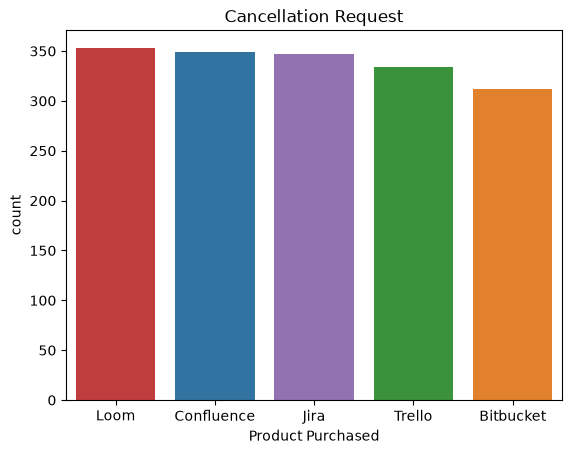

In [59]:
# Which product has the most amount of cancellation requests
sns.countplot(data=cancellation_requests,
              x="Product Purchased",
              hue="Product Purchased",
              order=["Loom", "Confluence", "Jira", "Trello", "Bitbucket"],
              hue_order=["Confluence","Bitbucket", "Trello", "Loom",  "Jira" ]).set_title("Cancellation Request")

## Find the percentage of cancellation requests per product

In [60]:
# get the all the requests
all = customer_support_tickets

# get the closed ones
cancellation = all[["Product Purchased", "Ticket Type"]]
cancellation_df = cancellation.groupby(["Product Purchased", "Ticket Type"]).size().reset_index(name="count")

# calculate the percentage within each Product Purchased group
cancellation_df["percentage"] = (
    cancellation_df.groupby("Product Purchased")["count"]
    .transform(lambda x: (x / x.sum()) * 100)
)
cancellation_df = cancellation_df.sort_values(["Product Purchased", "Ticket Type", "percentage"], ascending=False)
cancellation_df[cancellation_df["Ticket Type"] == "Cancellation request"].sort_values("percentage", ascending=False)


,Product Purchased,Ticket Type,count,percentage
16,Loom,Cancellation request,353,21.669736
21,Trello,Cancellation request,334,20.528580
1,Bitbucket,Cancellation request,312,19.561129
11,Jira,Cancellation request,347,19.418019
6,Confluence,Cancellation request,349,19.060623


In [61]:
# get the all the requests
all = customer_support_tickets

# get the closed ones
closed = all[all["Ticket Status"] == "Closed"]
closed = all[["Product Purchased", "Ticket Type", "Ticket Subject", "Customer Satisfaction Rating"]]
closed_df = closed.groupby(["Product Purchased", "Ticket Type"])["Customer Satisfaction Rating"].mean().reset_index().sort_values(["Product Purchased", "Ticket Type", "Customer Satisfaction Rating"], ascending=True)
closed_df


,Product Purchased,Ticket Type,Customer Satisfaction Rating
0,Bitbucket,Billing inquiry,2.924731
1,Bitbucket,Cancellation request,3.109890
2,Bitbucket,Product inquiry,2.937500
3,Bitbucket,Refund request,2.896825
4,Bitbucket,Technical issue,2.892562
5,Confluence,Billing inquiry,3.037383
6,Confluence,Cancellation request,2.836957
7,Confluence,Product inquiry,3.000000
8,Confluence,Refund request,3.129032
9,Confluence,Technical issue,3.041322


In [62]:
closed_df[closed_df["Ticket Type"] == "Cancellation request"].sort_values("Customer Satisfaction Rating")

,Product Purchased,Ticket Type,Customer Satisfaction Rating
6,Confluence,Cancellation request,2.836957
16,Loom,Cancellation request,3.000000
21,Trello,Cancellation request,3.063636
1,Bitbucket,Cancellation request,3.109890
11,Jira,Cancellation request,3.125000


In [63]:
# get the all the requests
all = customer_support_tickets

# get the closed ones
closed = all[all["Ticket Status"] == "Closed"]
closed = all[["Product Purchased", "Ticket Type", "Ticket Subject", "Customer Satisfaction Rating"]]
closed_df = closed.groupby(["Product Purchased"])["Customer Satisfaction Rating"].mean().reset_index().sort_values(["Customer Satisfaction Rating"], ascending=True)
closed_df

,Product Purchased,Customer Satisfaction Rating
0,Bitbucket,2.944972
2,Jira,2.962264
4,Trello,2.974729
1,Confluence,3.017762
3,Loom,3.057196


### Refunds + Cancellations (Churn)

In [64]:
# get the all the requests
all = customer_support_tickets

# get the closed ones
refund_cancel = all[["Product Purchased", "Ticket Type"]]
refund_cancel["Churn"] = refund_cancel["Ticket Type"].isin(["Refund request", "Cancellation request"])
refund_cancel.drop(columns=["Ticket Type"])
refund_cancel_df = refund_cancel.groupby(["Product Purchased", "Churn"]).size().reset_index(name="count")

# calculate the percentage within each Product Purchased group
refund_cancel_df["percentage"] = (
    refund_cancel_df.groupby("Product Purchased")["count"]
    .transform(lambda x: (x / x.sum()) * 100)
)

refund_cancel_df = refund_cancel_df.sort_values(["Product Purchased", "Churn", "percentage"], ascending=False)
refund_cancel_df[refund_cancel_df["Churn"]].sort_values("percentage", ascending=False)


,Product Purchased,Churn,count,percentage
7,Loom,True,687,42.173112
9,Trello,True,682,41.917640
1,Bitbucket,True,668,41.880878
3,Confluence,True,726,39.650464
5,Jira,True,684,38.276441


In [65]:
# get the all the requests
all = customer_support_tickets

# get the closed ones
closed = all[all["Ticket Status"] == "Closed"]
closed["Churn"] = closed["Ticket Type"].isin(["Cancellation request", "Refund request"])

closed = closed[["Product Purchased", "Churn", "Customer Satisfaction Rating"]]

closed_df = closed.groupby(["Product Purchased", "Churn"])["Customer Satisfaction Rating"].mean().reset_index().sort_values(["Customer Satisfaction Rating"], ascending=True)
closed_df[closed_df["Churn"]].sort_values("Customer Satisfaction Rating")


,Product Purchased,Churn,Customer Satisfaction Rating
7,Loom,True,2.906780
9,Trello,True,2.965368
1,Bitbucket,True,2.986175
3,Confluence,True,3.004630
5,Jira,True,3.037736


In [66]:
closed_df[closed_df["Churn"] == False].sort_values("Customer Satisfaction Rating")

,Product Purchased,Churn,Customer Satisfaction Rating
0,Bitbucket,False,2.916129
4,Jira,False,2.919137
8,Trello,False,2.981424
2,Confluence,False,3.025937
6,Loom,False,3.173203


In [67]:
closed = customer_support_tickets[customer_support_tickets["Ticket Status"] == "Closed"]
print("Number of No-ratings in Closed Tickets")
int(closed["Customer Satisfaction Rating"].isna().sum())

Number of No-ratings in Closed Tickets


0

In [68]:
# get the all the requests
all = customer_support_tickets

# get the closed ones
closed = all[all["Ticket Status"] == "Closed"]
closed = all[["Product Purchased", "Ticket Type", "Ticket Subject", "Customer Satisfaction Rating"]]
closed_df = closed.groupby(["Product Purchased"])["Customer Satisfaction Rating"].mean().reset_index().sort_values(["Customer Satisfaction Rating"], ascending=True)
closed_df

,Product Purchased,Customer Satisfaction Rating
0,Bitbucket,2.944972
2,Jira,2.962264
4,Trello,2.974729
1,Confluence,3.017762
3,Loom,3.057196


# Findings:
 - Loom has the highest percentage of cancellation/refund requests.
 - The average customer satisfaction rating is pretty high for non-churn related requests (So is there a particular type of request that is dragging it down?)


# Goal:
 - What can we do to reduce the churn rate of Loom?
 - Why are the people cancelling?


In [69]:
loom = pd.read_csv(
    "customer_support_tickets.csv"
)

loom.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,Jira,22-03-2021,Technical issue,Product setup,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,Confluence,22-05-2021,Technical issue,Integration,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Trello,14-07-2020,Technical issue,Network problem,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Loom,13-11-2020,Billing inquiry,Account access,Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Bitbucket,04-02-2020,Billing inquiry,Data loss,Closed,West decision evidence bit.,Low,Email,01-06-2023 00:12,01-06-2023 19:53,1.0


In [70]:
loom["Ticket Subject"].value_counts()

Ticket Subject
Refund request                576
Software bug                  574
Product compatibility         567
Email delivery problem        561
Device compatibility issue    547
Loading issue                 542
Network problem               539
Installation support          530
Product setup                 529
Payment issue                 526
Product recommendation        517
Account access                509
Integration                   496
Data loss                     491
Cancellation request          487
Display issue                 478
Name: count, dtype: int64

In [71]:
loom["Ticket Type"].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [72]:
loom = loom[["Product Purchased", "Ticket Subject", "Ticket Priority", "Ticket Channel", "Customer Satisfaction Rating", "Ticket Status"]]
loom = loom[loom["Product Purchased"] == "Loom"]
loom = loom[loom["Ticket Status"] == "Closed"]

avg_rating_subject = loom.groupby(
    "Ticket Subject"
)["Customer Satisfaction Rating"].mean()

avg_rating_subject = avg_rating_subject.reset_index(name="avg_rating")
avg_rating_subject = avg_rating_subject.sort_values("avg_rating", ascending=True)
avg_rating_subject


,Ticket Subject,avg_rating
3,Device compatibility issue,2.794118
5,Email delivery problem,2.833333
12,Product recommendation,2.842105
10,Payment issue,2.884615
13,Product setup,2.895833
4,Display issue,2.931034
0,Account access,2.947368
9,Network problem,2.950000
7,Integration,2.967742
14,Refund request,3.030303


In [73]:
count_rating_subject = loom.groupby(
    "Ticket Subject"
).size()

count_rating_subject = count_rating_subject.reset_index(name="count_rating")
count_rating_subject = count_rating_subject.sort_values("count_rating", ascending=False)
count_rating_subject


,Ticket Subject,count_rating
13,Product setup,48
11,Product compatibility,45
15,Software bug,45
9,Network problem,40
0,Account access,38
12,Product recommendation,38
6,Installation support,34
3,Device compatibility issue,34
14,Refund request,33
7,Integration,31


# Joins

In [74]:
customers = pd.read_csv("customers.csv")
customer_tickets = pd.read_csv("customer_support_tickets.csv")
merged_df = pd.merge(
    customer_tickets, 
    customers, 
    on=['Customer Email', 'Customer Name', 'Customer Age', 'Customer Gender'], 
    how='left'
)

In [75]:
loom_merged = merged_df[merged_df["Product Purchased"] == "Loom"]
loom_merged_ind_tickets = loom_merged[["Ticket Type", "Ticket Subject", "Ticket Status", "Customer Satisfaction Rating", "Industry", "Company Size", "Plan Type"]]
loom_merged_ind_tickets.head()

,Ticket Type,Ticket Subject,Ticket Status,Customer Satisfaction Rating,Industry,Company Size,Plan Type
3,Billing inquiry,Account access,Closed,3.0,Professional Services,51-200,Premium
5,Cancellation request,Payment issue,Open,NaN,Healthcare,51-200,Free
9,Refund request,Payment issue,Pending Customer Response,NaN,Financial Services,51-200,Standard
14,Billing inquiry,Product setup,Closed,4.0,Manufacturing,1-10,Premium
20,Refund request,Payment issue,Pending Customer Response,NaN,Media & Communications,1-10,Standard


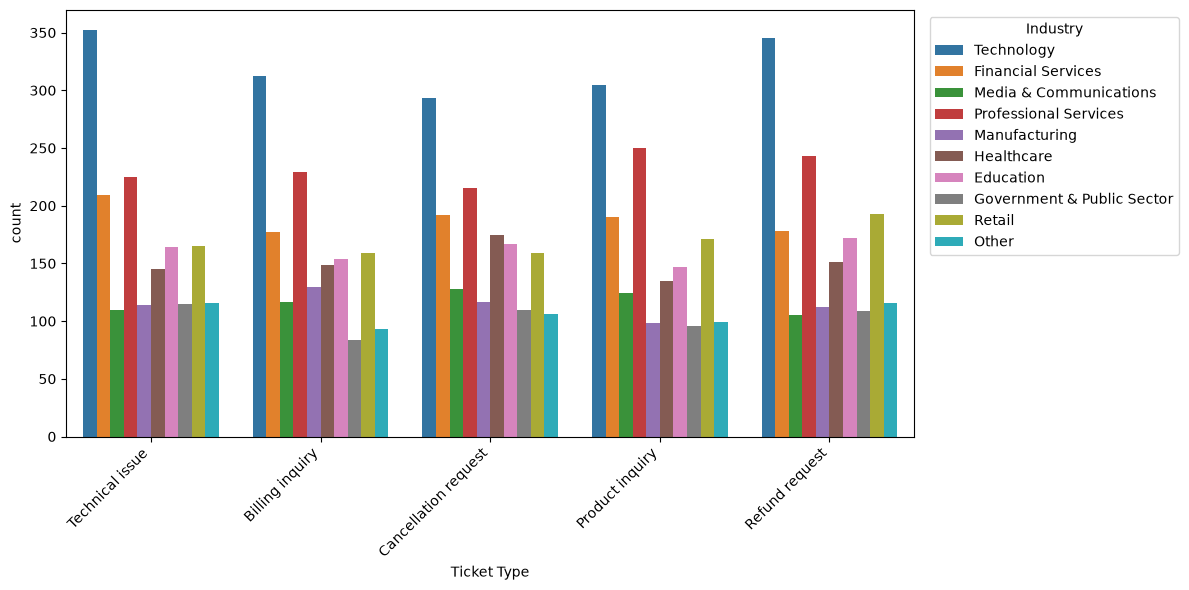

In [76]:
# 1. Increase the figure size to give the grouped bars more breathing room
plt.figure(figsize=(12, 6))

# 2. Generate the plot (assuming your dataframe is 'merged_df')
ax = sns.countplot(data=merged_df, x='Ticket Type', hue='Industry')

# 3. Rotate the x-axis labels 45 degrees so they don't overlap
plt.xticks(rotation=45, ha='right')

# 4. Move the legend outside the top right of the plot area
plt.legend(title='Industry', bbox_to_anchor=(1.01, 1), loc='upper left')

# 5. Automatically adjust subplots to fit the external legend and rotated labels
plt.tight_layout()

plt.show()

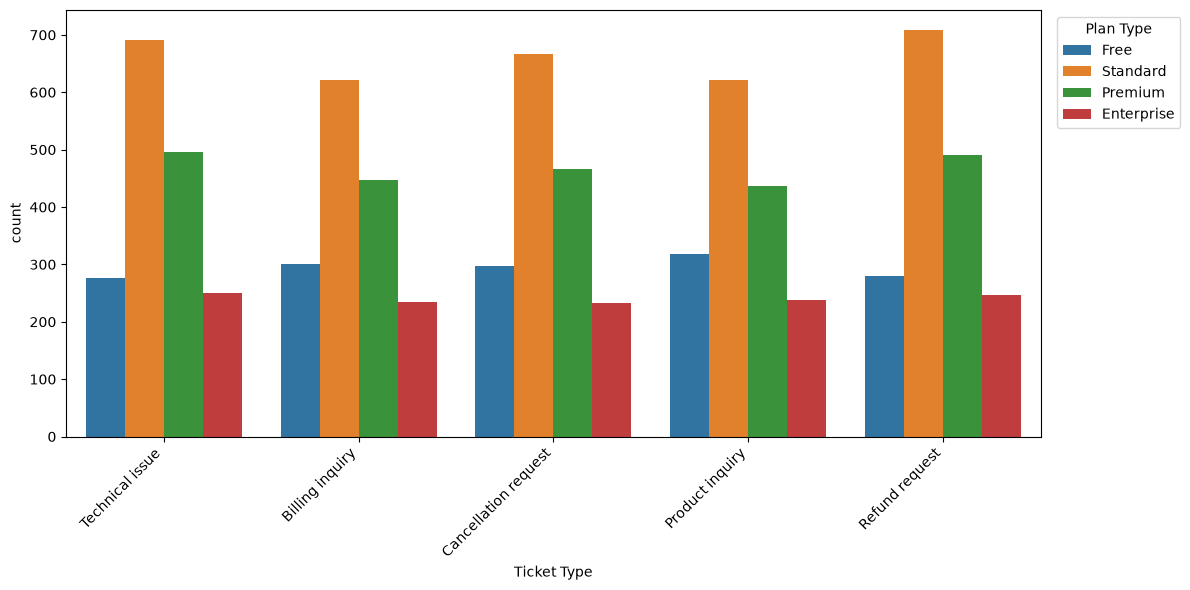

In [77]:
# 1. Increase the figure size to give the grouped bars more breathing room
plt.figure(figsize=(12, 6))

# 2. Generate the plot (assuming your dataframe is 'merged_df')
ax = sns.countplot(data=merged_df, x='Ticket Type', hue='Plan Type')

# 3. Rotate the x-axis labels 45 degrees so they don't overlap
plt.xticks(rotation=45, ha='right')

# 4. Move the legend outside the top right of the plot area
plt.legend(title='Plan Type', bbox_to_anchor=(1.01, 1), loc='upper left')

# 5. Automatically adjust subplots to fit the external legend and rotated labels
plt.tight_layout()

plt.show()

#### Plan Type Percentages

In [78]:
# get the closed ones
refund_cancel = loom_merged_ind_tickets[["Plan Type", "Ticket Type"]]
refund_cancel["Churn"] = refund_cancel["Ticket Type"].isin(["Refund request", "Cancellation request"])
refund_cancel.drop(columns=["Ticket Type"])
refund_cancel_df = refund_cancel.groupby(["Plan Type", "Churn"]).size().reset_index(name="count")

# calculate the percentage within each Product Purchased group
refund_cancel_df["percentage"] = (
    refund_cancel_df.groupby("Plan Type")["count"]
    .transform(lambda x: (x / x.sum()) * 100)
)

refund_cancel_df = refund_cancel_df.sort_values(["Plan Type", "Churn", "percentage"], ascending=False)
refund_cancel_df[refund_cancel_df["Churn"]].sort_values("percentage", ascending=False)

,Plan Type,Churn,count,percentage
5,Premium,True,190,43.181818
7,Standard,True,281,43.032159
1,Enterprise,True,92,39.826840
3,Free,True,109,38.790036


<Axes: xlabel='Plan Type', ylabel='percentage'>

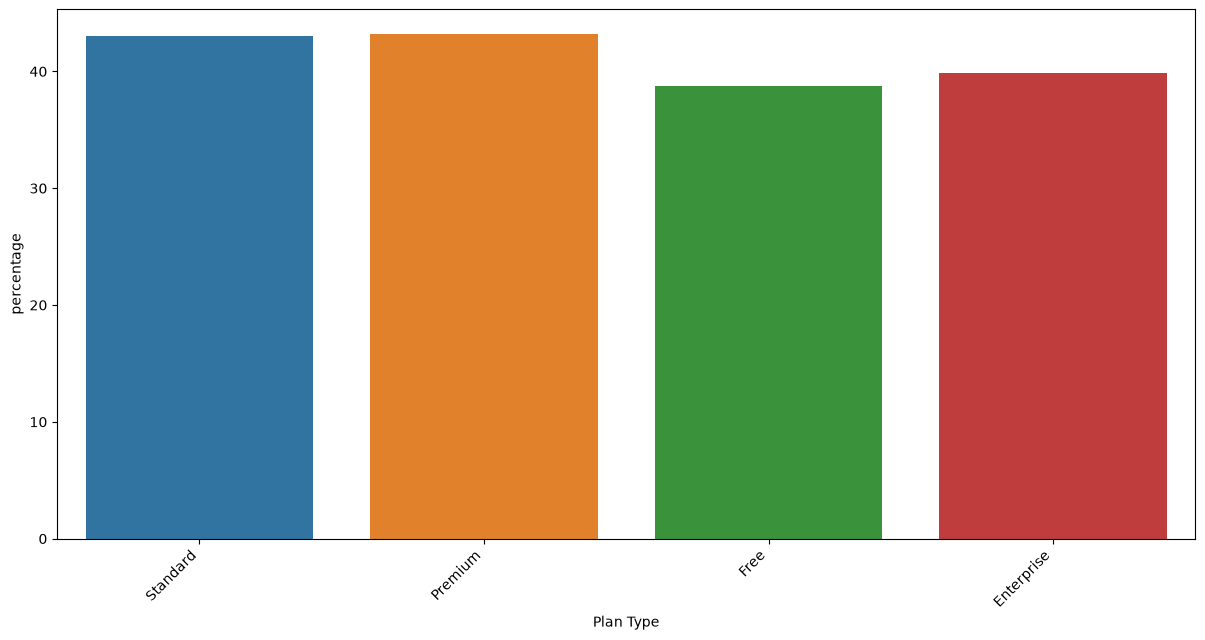

In [79]:
refund_cancel_df_plan_types = refund_cancel_df[refund_cancel_df["Churn"]]
refund_cancel_df_plan_types = refund_cancel_df_plan_types[["Plan Type", "percentage"]]
plt.figure(figsize=(12, 6))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
sns.barplot(data=refund_cancel_df_plan_types,
            x="Plan Type",
            y="percentage",
            hue="Plan Type")

### Industry Percentages

In [80]:
# get the closed ones
refund_cancel = loom_merged_ind_tickets[["Industry", "Ticket Type"]]
refund_cancel["Churn"] = refund_cancel["Ticket Type"].isin(["Refund request", "Cancellation request"])
refund_cancel.drop(columns=["Ticket Type"])
refund_cancel_df = refund_cancel.groupby(["Industry", "Churn"]).size().reset_index(name="count")

# calculate the percentage within each Product Purchased group
refund_cancel_df["percentage"] = (
    refund_cancel_df.groupby("Industry")["count"]
    .transform(lambda x: (x / x.sum()) * 100)
)

refund_cancel_df = refund_cancel_df.sort_values(["Industry", "Churn", "percentage"], ascending=False)
refund_cancel_df[refund_cancel_df["Churn"]].sort_values("percentage", ascending=False)

,Industry,Churn,count,percentage
5,Government & Public Sector,True,46,48.421053
11,Media & Communications,True,50,47.169811
7,Healthcare,True,74,47.133758
1,Education,True,74,44.848485
17,Retail,True,74,43.274854
9,Manufacturing,True,42,41.176471
19,Technology,True,125,39.936102
15,Professional Services,True,86,38.738739
13,Other,True,38,38.000000
3,Financial Services,True,63,36.206897


<Axes: xlabel='Industry', ylabel='percentage'>

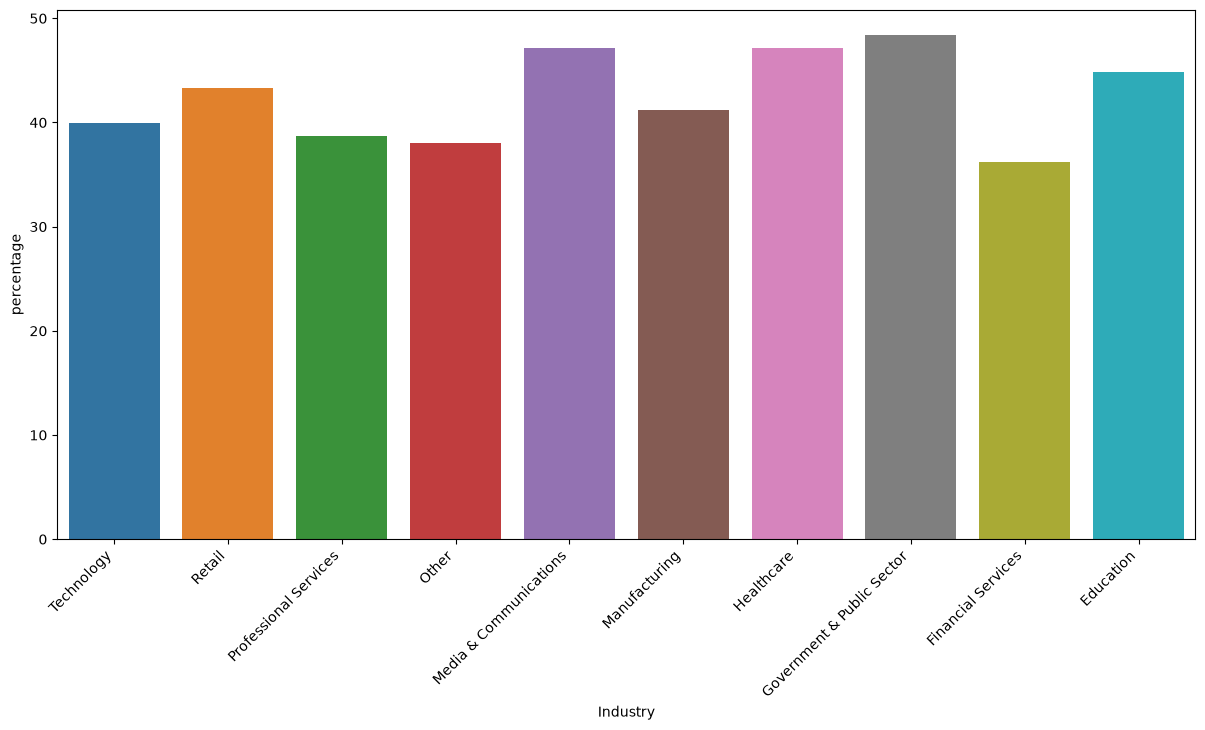

In [81]:
refund_cancel_df_plan_types = refund_cancel_df[refund_cancel_df["Churn"]]
refund_cancel_df_plan_types = refund_cancel_df_plan_types[["Industry", "percentage"]]
plt.figure(figsize=(12, 6))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
sns.barplot(data=refund_cancel_df_plan_types,
            x="Industry",
            y="percentage",
            hue="Industry")